In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Makes plots appear inside the notebook
%matplotlib inline

In [2]:
df=pd.read_csv('/content/drive/MyDrive/AI-Powered-Supply-Chain-Analytics/data/processed/DataCoSupplyChainDataset_Clean.csv',encoding='latin1')

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,NaN,1360,73,NaN,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,NaN,1360,73,NaN,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,NaN,1360,73,NaN,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,NaN,1360,73,NaN,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,NaN,1360,73,NaN,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [5]:
df.shape

(180519, 46)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment              

In [10]:
(df.columns)

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product Description', 'Product Name', 'Product Price',
       'Product Status', 'shipping date (DateOrders)', 'Shipping Mode'],
      dtyp

In [13]:
category_sales = (
    df.groupby("Category Name")["Sales"].sum().sort_values(ascending=False).round(2)
)

category_sales

,Sales
Category Name,
Fishing,6929653.69
Cleats,4431942.78
Camping & Hiking,4118425.57
Cardio Equipment,3694843.20
Women's Apparel,3147800.00
Water Sports,3113844.68
Men's Footwear,2891757.66
Indoor/Outdoor Games,2888993.91
Shop By Sport,1309522.04


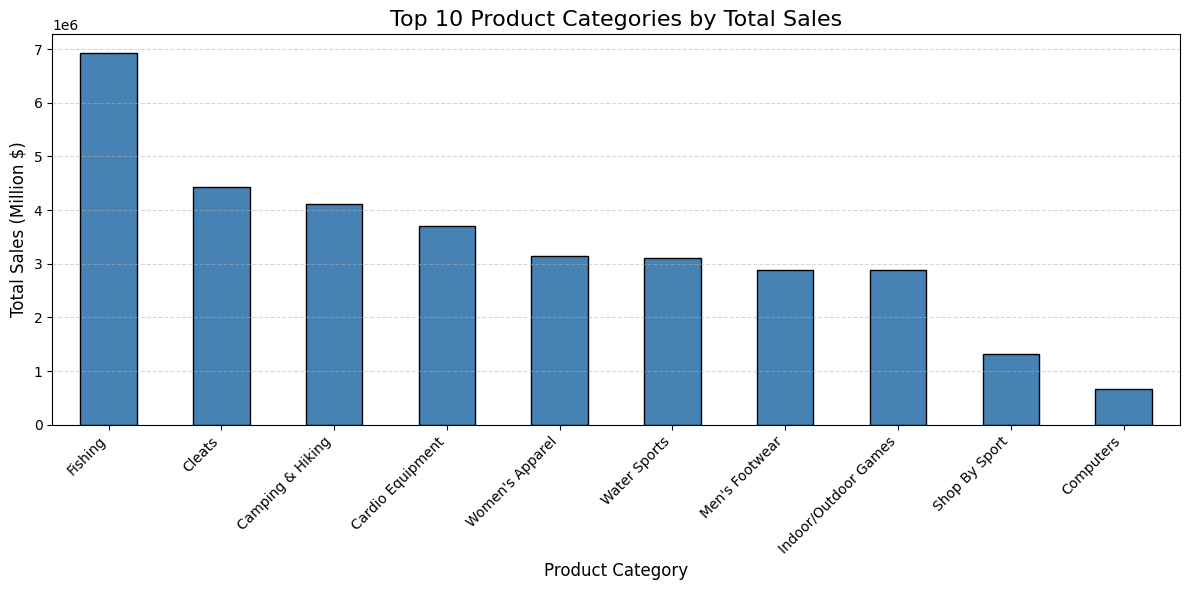

In [15]:
plt.figure(figsize=(12,6))

category_sales.head(10).plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Product Categories by Total Sales", fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Sales (Million $)", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [17]:
df[["Order Profit Per Order", "Order Item Profit Ratio"]].head()

,Order Profit Per Order,Order Item Profit Ratio
0,91.250000,0.29
1,-249.089996,-0.80
2,-247.779999,-0.80
3,22.860001,0.08
4,134.210007,0.45


In [18]:
category_profit = (
    df.groupby("Category Name")["Order Profit Per Order"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)

category_profit

,Order Profit Per Order
Category Name,
Fishing,756220.77
Cleats,494636.92
Camping & Hiking,427455.57
Cardio Equipment,383011.10
Women's Apparel,350421.03
Water Sports,325146.96
Indoor/Outdoor Games,318451.43
Men's Footwear,311902.82
Shop By Sport,129813.96


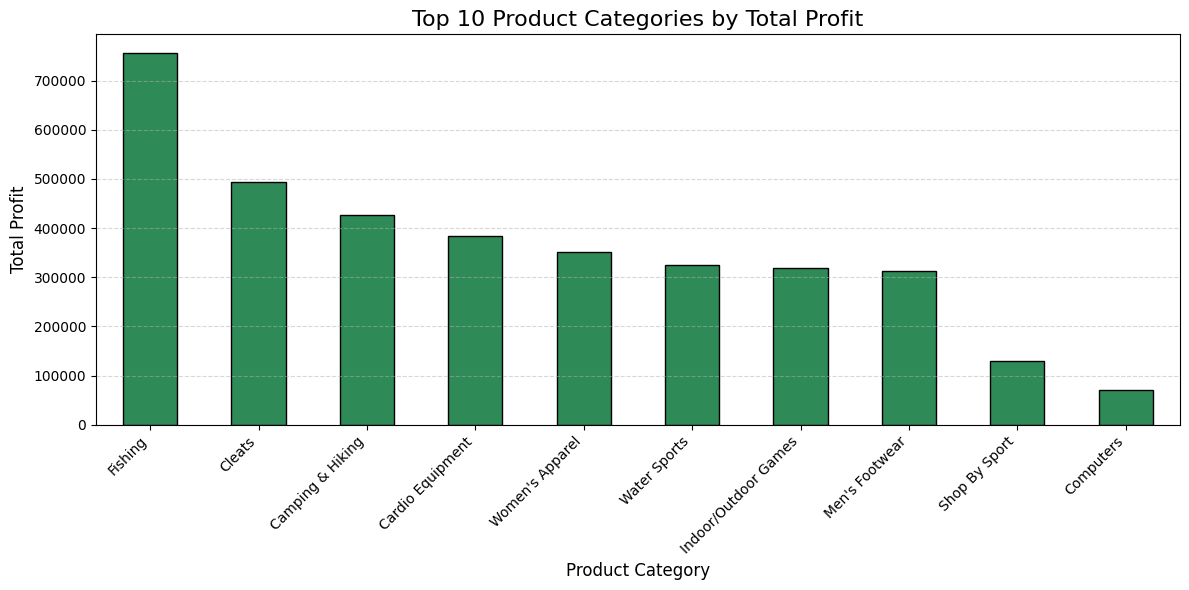

In [19]:
plt.figure(figsize=(12,6))

category_profit.head(10).plot(
    kind="bar",
    color="seagreen",
    edgecolor="black"
)

plt.title("Top 10 Product Categories by Total Profit", fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Profit", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [20]:
customer_sales = (
    df.groupby("Customer Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)

customer_sales

,Sales
Customer Segment,
Consumer,19095790.16
Corporate,11168406.84
Home Office,6520538.02


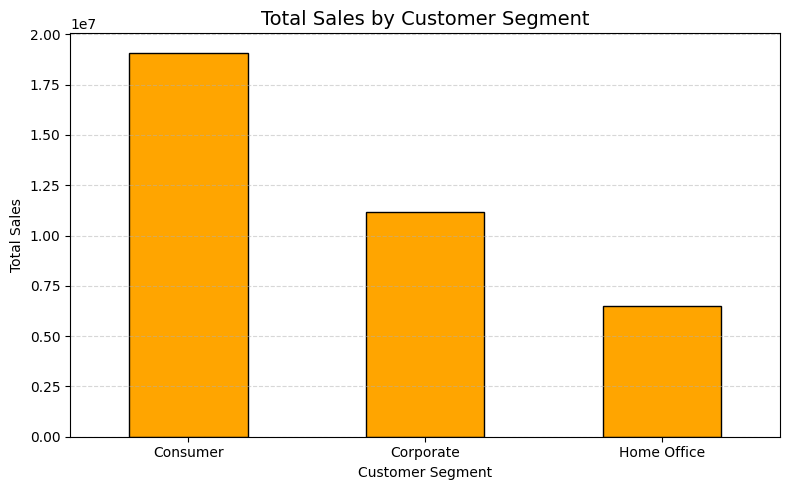

In [21]:
plt.figure(figsize=(8,5))

customer_sales.plot(
    kind="bar",
    color="orange",
    edgecolor="black"
)

plt.title("Total Sales by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [22]:
market_sales = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)

market_sales

,Sales
Market,
Europe,10872396.80
LATAM,10277612.84
Pacific Asia,8273743.74
USCA,5066528.71
Africa,2294452.93


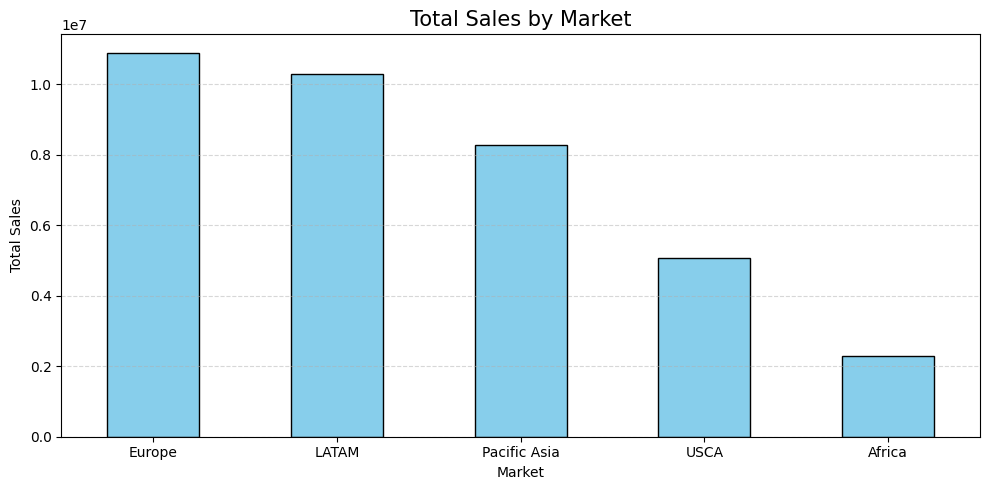

In [23]:
plt.figure(figsize=(10,5))

market_sales.plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Total Sales by Market", fontsize=15)
plt.xlabel("Market")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [24]:
country_sales = (
    df.groupby("Order Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)

country_sales.head(10)

,Sales
Order Country,
Estados Unidos,4879667.67
Francia,2879942.36
MÃ©xico,2633195.29
Alemania,2074171.82
Australia,1694621.67
Reino Unido,1612094.85
Brasil,1594319.95
China,1172902.11
Italia,1072181.67


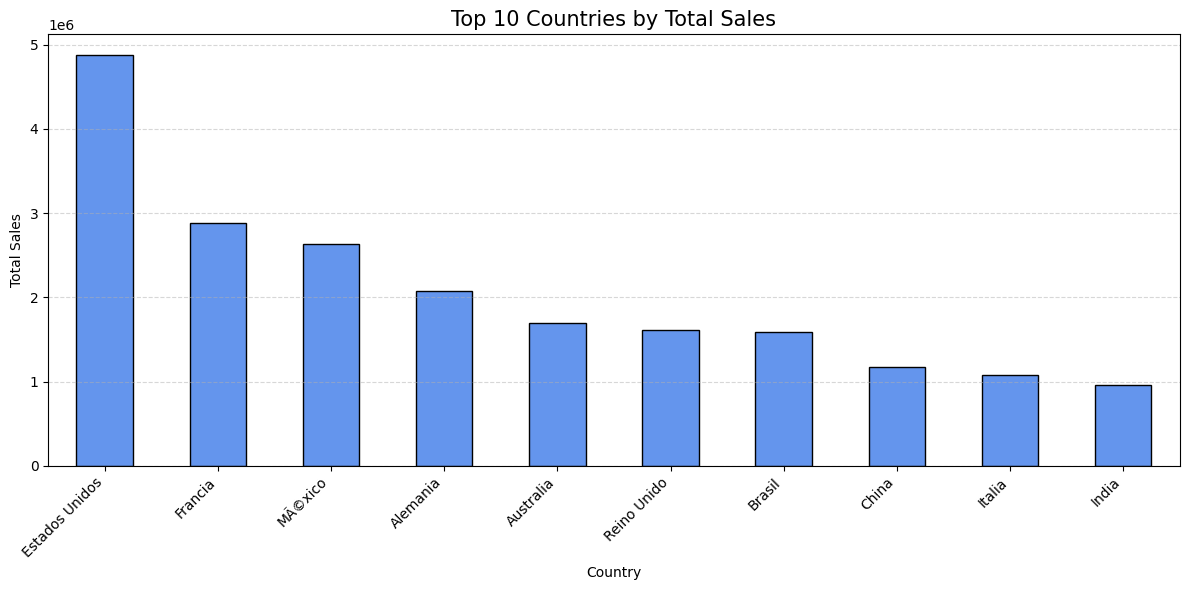

In [25]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(
    kind="bar",
    color="cornflowerblue",
    edgecolor="black"
)

plt.title("Top 10 Countries by Total Sales", fontsize=15)
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [26]:
segment_category_sales = (
    df.groupby(["Customer Segment", "Category Name"])["Sales"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)

segment_category_sales.head(15)

Customer Segment  Category Name       
Consumer          Fishing                 3609019.64
                  Cleats                  2292758.47
                  Camping & Hiking        2112759.22
Corporate         Fishing                 2094695.32
Consumer          Cardio Equipment        1936977.63
                  Water Sports            1624968.93
                  Women's Apparel         1623900.00
                  Men's Footwear          1491245.34
                  Indoor/Outdoor Games    1490603.51
Corporate         Cleats                  1322540.10
                  Camping & Hiking        1263815.79
Home Office       Fishing                 1225938.73
Corporate         Cardio Equipment        1113809.46
                  Women's Apparel          967550.00
                  Water Sports             937453.26
Name: Sales, dtype: float64

In [27]:
category_sales_profit = (
    df.groupby("Category Name")
      .agg({
          "Sales": "sum",
          "Order Profit Per Order": "sum"
      })
      .sort_values(by="Sales", ascending=False)
      .round(2)
)

category_sales_profit

,Sales,Order Profit Per Order
Category Name,,
Fishing,6929653.69,756220.77
Cleats,4431942.78,494636.92
Camping & Hiking,4118425.57,427455.57
Cardio Equipment,3694843.20,383011.10
Women's Apparel,3147800.00,350421.03
Water Sports,3113844.68,325146.96
Men's Footwear,2891757.66,311902.82
Indoor/Outdoor Games,2888993.91,318451.43
Shop By Sport,1309522.04,129813.96


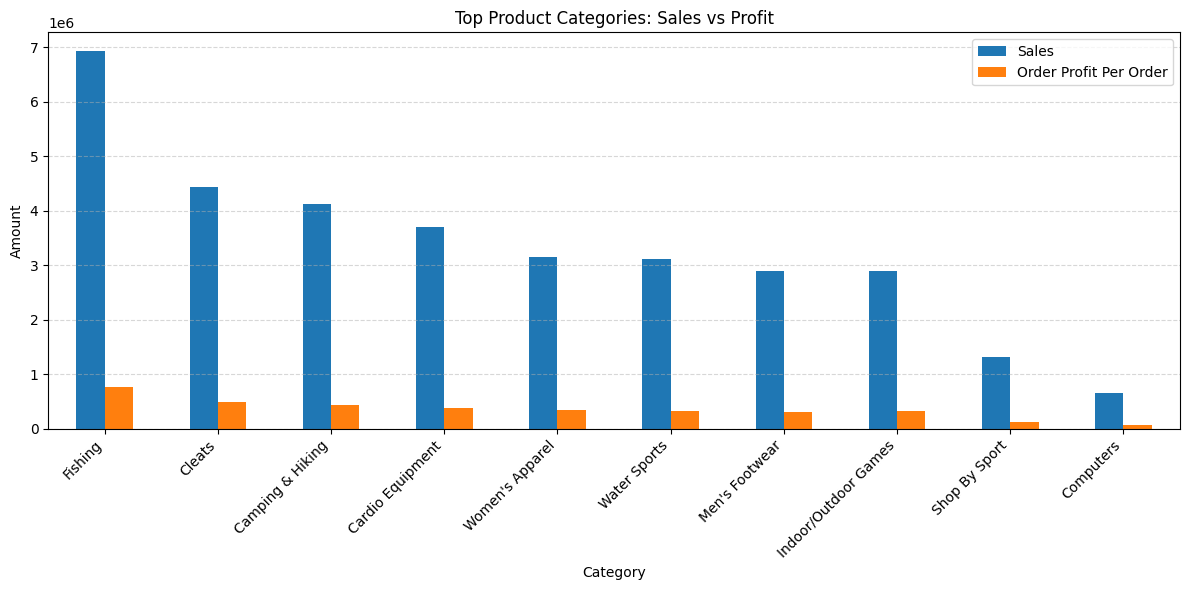

In [28]:
category_sales_profit.head(10).plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top Product Categories: Sales vs Profit")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Shipping Analysis

In [29]:
shipping_mode = (
    df["Shipping Mode"]
      .value_counts()
)

shipping_mode

,count
Shipping Mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737


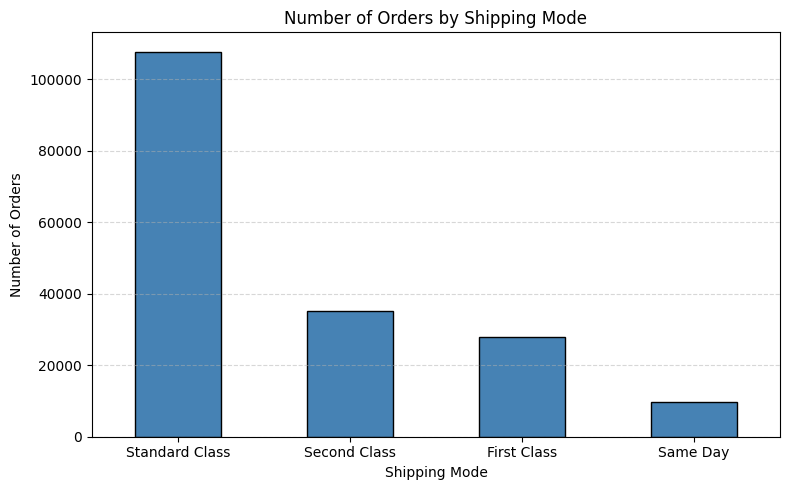

In [30]:
plt.figure(figsize=(8,5))

shipping_mode.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Number of Orders by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [31]:
delivery_status = df["Delivery Status"].value_counts()

delivery_status

,count
Delivery Status,
Late delivery,98977
Advance shipping,41592
Shipping on time,32196
Shipping canceled,7754


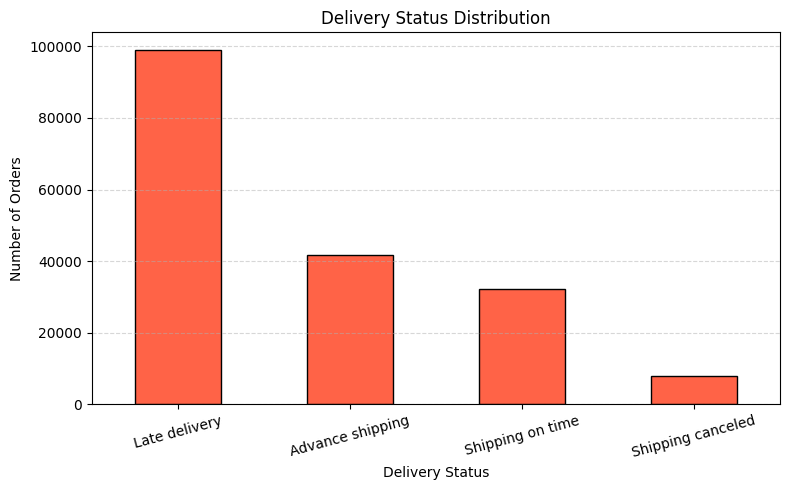

In [32]:
plt.figure(figsize=(8,5))

delivery_status.plot(
    kind="bar",
    color="tomato",
    edgecolor="black"
)

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=15)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

In [33]:
late_risk = df["Late_delivery_risk"].value_counts()

late_risk

,count
Late_delivery_risk,
1,98977
0,81542


In [34]:
df[
    [
        "Days for shipping (real)",
        "Days for shipment (scheduled)"
    ]
].describe()

,Days for shipping (real),Days for shipment (scheduled)
count,180519.000000,180519.000000
mean,3.497654,2.931847
std,1.623722,1.374449
min,0.000000,0.000000
25%,2.000000,2.000000
50%,3.000000,4.000000
75%,5.000000,4.000000
max,6.000000,4.000000


# Time series Analysis

In [46]:
print(df["order date (DateOrders)"].dtype)
print(df_clean["order date (DateOrders)"].dtype)

object
object


In [48]:
# Convert date columns to datetime
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"]
)

df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"]
)

In [49]:
print(df["order date (DateOrders)"].dtype)

datetime64[ns]


In [50]:
monthly_sales = (
    df.groupby(
        df["order date (DateOrders)"].dt.to_period("M")
    )["Sales"]
    .sum()
)

monthly_sales

,Sales
order date (DateOrders),
2015-01,1.051590e+06
2015-02,9.270099e+05
2015-03,1.051254e+06
2015-04,1.014463e+06
2015-05,1.050478e+06
2015-06,1.024006e+06
2015-07,1.038081e+06
2015-08,1.029495e+06
2015-09,1.018339e+06


# Correlation Analysis

In [40]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

correlation

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Department Id,Latitude,Longitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
Days for shipping (real),1.000000,0.515880,-0.005101,0.001757,0.401415,-0.000348,0.003432,-0.001631,-0.004073,0.003911,...,-0.000811,0.001962,0.001757,-0.005101,-0.000811,-0.000859,-0.000348,NaN,0.002185,NaN
Days for shipment (scheduled),0.515880,1.000000,-0.000185,0.006445,-0.369352,-0.000367,0.000899,-0.000262,-0.005300,0.003675,...,-0.002925,0.006327,0.006445,-0.000185,0.005249,-0.000431,-0.000367,NaN,0.006912,NaN
Benefit per order,-0.005101,-0.000185,1.000000,0.133484,-0.003727,0.031889,0.009354,0.031442,0.000338,-0.002521,...,0.015696,0.131816,0.133484,1.000000,-0.004978,0.033161,0.031889,NaN,0.103459,NaN
Sales per customer,0.001757,0.006445,0.133484,1.000000,-0.003791,0.225201,0.060181,0.232367,-0.000223,0.001444,...,0.105413,0.989744,1.000000,0.133484,-0.000138,0.236367,0.225201,NaN,0.781781,NaN
Late_delivery_risk,0.401415,-0.369352,-0.003727,-0.003791,1.000000,0.001752,0.001484,0.001077,0.000679,-0.001915,...,-0.000139,-0.003564,-0.003791,-0.003727,-0.014131,0.001490,0.001752,NaN,-0.002175,NaN
Category Id,-0.000348,-0.000367,0.031889,0.225201,0.001752,1.000000,0.274633,0.888835,0.002195,-0.002320,...,-0.302408,0.227483,0.225201,0.031889,-0.005943,0.991092,1.000000,NaN,0.461059,NaN
Customer Id,0.003432,0.000899,0.009354,0.060181,0.001484,0.274633,1.000000,0.136897,0.002335,-0.005146,...,-0.091328,0.060961,0.060181,0.009354,-0.005659,0.228039,0.274633,NaN,0.111118,NaN
Department Id,-0.001631,-0.000262,0.031442,0.232367,0.001077,0.888835,0.136897,1.000000,0.002460,-0.002435,...,-0.265437,0.234718,0.232367,0.031442,-0.005982,0.906117,0.888835,NaN,0.446743,NaN
Latitude,-0.004073,-0.005300,0.000338,-0.000223,0.000679,0.002195,0.002335,0.002460,1.000000,-0.525122,...,-0.001853,-0.000696,-0.000223,0.000338,-0.002921,0.002031,0.002195,NaN,0.000471,NaN
Longitude,0.003911,0.003675,-0.002521,0.001444,-0.001915,-0.002320,-0.005146,-0.002435,-0.525122,1.000000,...,0.004467,0.001696,0.001444,-0.002521,-0.005880,-0.002580,-0.002320,NaN,-0.000894,NaN


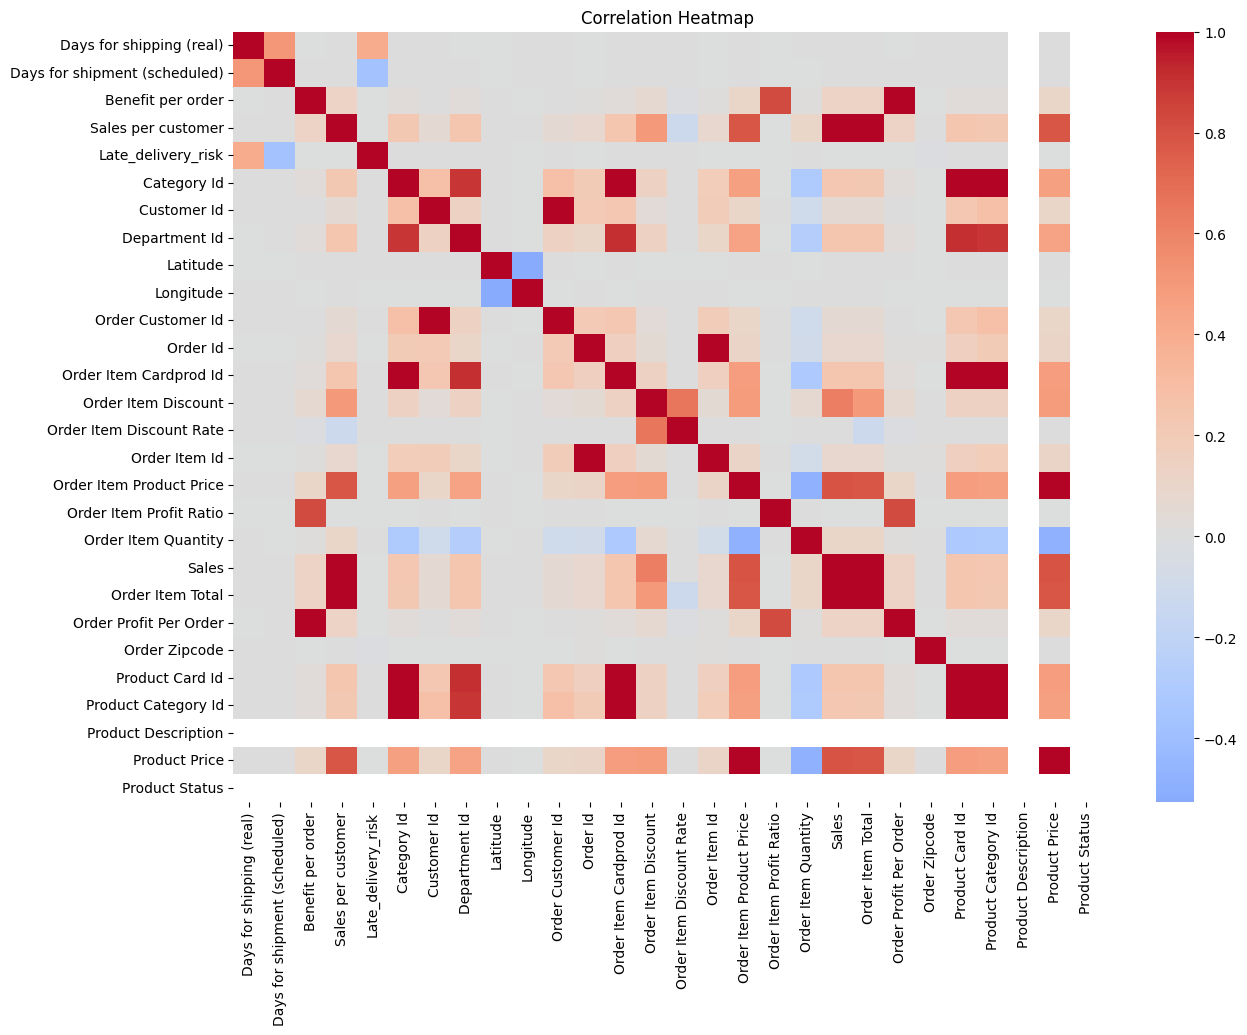

In [41]:

import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

# Advanced Business Insights

In [42]:

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products


,Sales
Product Name,
Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06
Perfect Fitness Perfect Rip Deck,4.421143e+06
Diamondback Women's Serene Classic Comfort Bi,4.118426e+06
Nike Men's Free 5.0+ Running Shoe,3.667633e+06
Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06
Pelican Sunstream 100 Kayak,3.099845e+06
Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06
O'Brien Men's Neoprene Life Vest,2.888994e+06
Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06


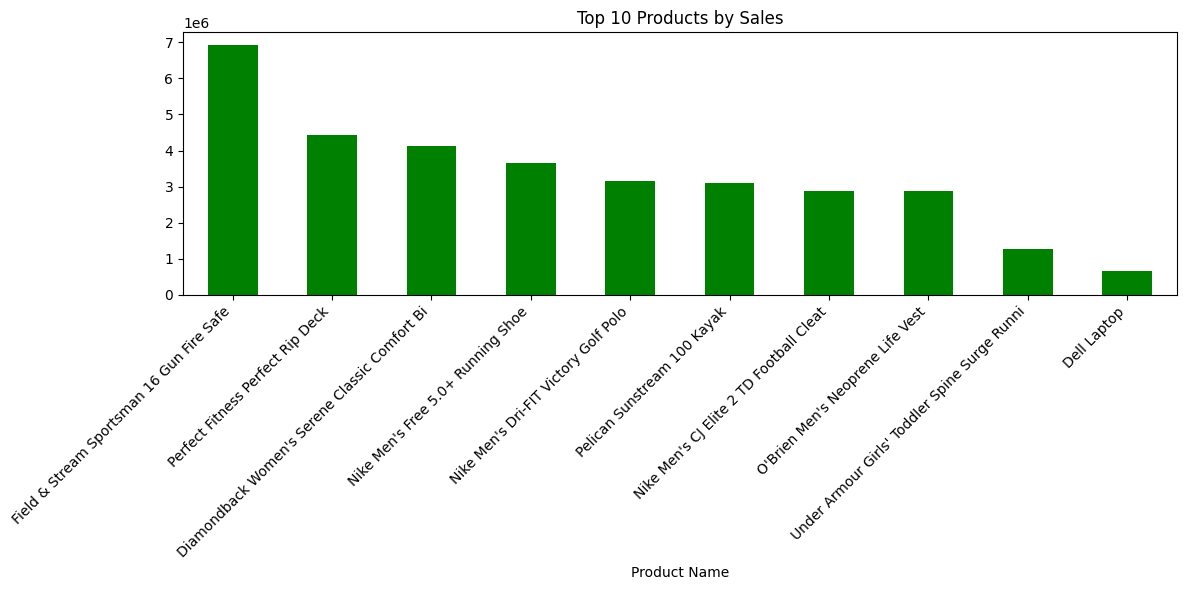

In [43]:
plt.figure(figsize=(12,6))

top_products.plot(
    kind="bar",
    color="green"
)

plt.title("Top 10 Products by Sales")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()